In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import kagglehub

In [6]:
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

print("Files in dataset:", os.listdir(path))
print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "dataset_phishing.csv"))
print("Первые 5 строк:")
print(df.head())
print("\nРазмер датасета:", df.shape)
print("\nИнформация о столбцах:")
print(df.info())


Files in dataset: ['dataset_phishing.csv']
Path to dataset files: C:\Users\ro517\.cache\kagglehub\datasets\shashwatwork\web-page-phishing-detection-dataset\versions\2
Первые 5 строк:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4  

In [8]:
print("Столбцы датасета:")
print(df.columns)
url_col = "url"
target_col = "status"


def normalize_target(x):
    x_str = str(x).strip().lower()
    
    phishing_values = "phishing"
    legit_values = "legitimate"
    
    if x_str in phishing_values:
        return 1
    if x_str in legit_values:
        return 0
df[target_col] = df[target_col].apply(normalize_target)
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)

print("\nРаспределение классов:")
print(y.value_counts())

print("\nПропуски:")
print(df.isnull().sum().sum())


Столбцы датасета:
Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'sta

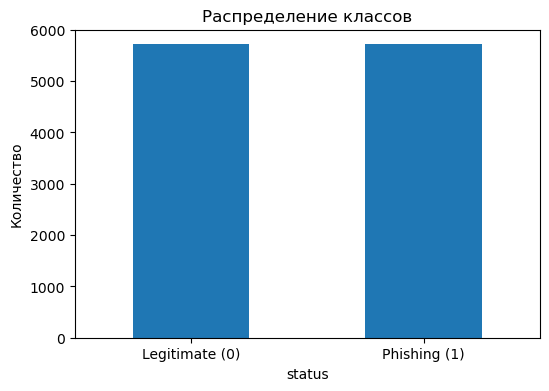

In [9]:
plt.figure(figsize=(6, 4))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Legitimate (0)", "Phishing (1)"], rotation=0)
plt.title("Распределение классов")
plt.ylabel("Количество")
plt.show()


Признаки:
   nb_dots  nb_slash  nb_hyphens  nb_qm  nb_eq  nb_at  domain_age  length_url  \
0        3         3           0      0      0      0          -1          37   
1        1         5           0      0      0      0        5767          77   
2        4         5           1      1      3      0        4004         126   
3        2         2           0      0      0      0          -1          18   
4        2         5           2      0      0      0        8175          55   

   length_hostname  https_token  http_in_path  status  
0               19            1             0       0  
1               23            1             0       1  
2               50            0             0       1  
3               11            1             0       0  
4               15            1             0       0  

Количество признаков: 11


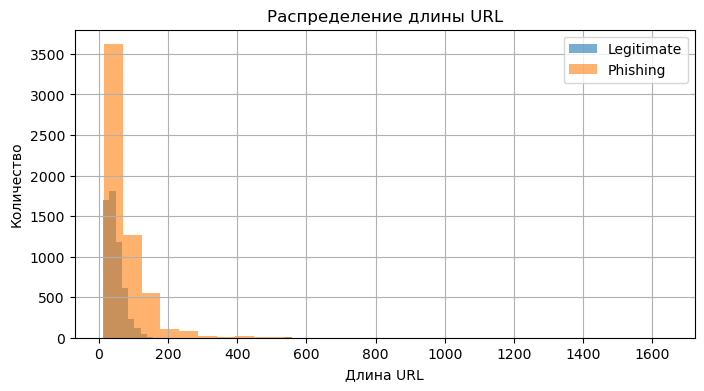

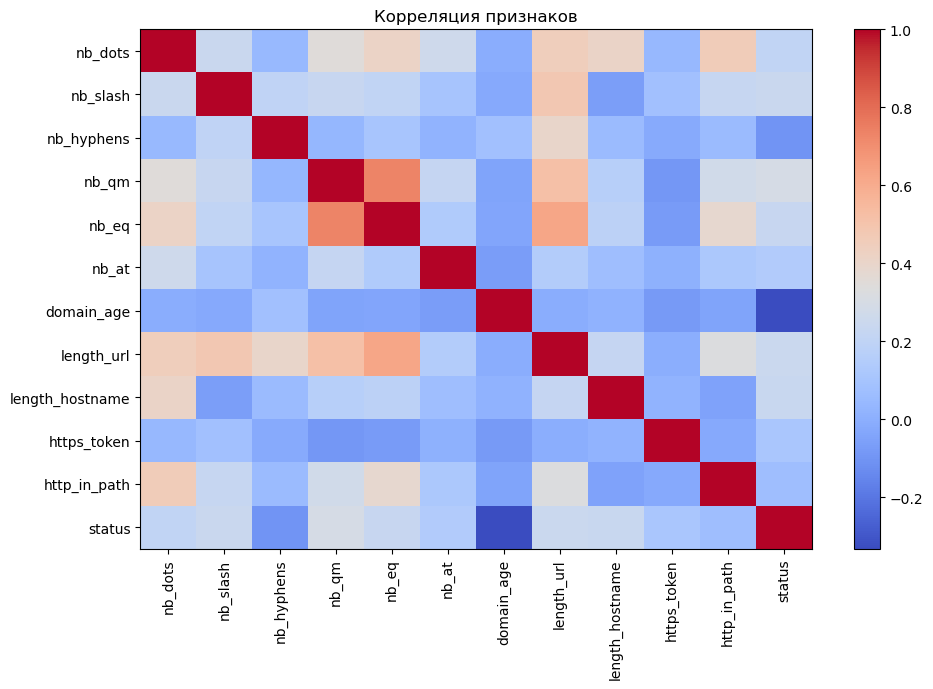


Размер X: (11430, 11)
Размер y: (11430,)

Распределение классов:
status
0    5715
1    5715
Name: count, dtype: int64


In [10]:
selected_features = [
    "nb_dots",           # количество точек в URL
    "nb_slash",          # количество слэшей
    "nb_hyphens",        # количество дефисов
    "nb_qm",             # количество знаков ?
    "nb_eq",             # количество знаков =
    "nb_at",             # количество символов @
    "domain_age",        # возраст домена
    "length_url",        # длина URL
    "length_hostname",   # длина хостнейма
    "https_token",       # есть SSL/TLS сертификат или нет
    "http_in_path"       # вложенная ссылка в пути
]

df_features = df[selected_features + [target_col]].copy()

print("\nПризнаки:")
print(df_features.head())

print("\nКоличество признаков:", len(selected_features))

plt.figure(figsize=(8, 4))
df_features[df_features[target_col] == 0]["length_url"].hist(alpha=0.6, bins=30, label="Legitimate")
df_features[df_features[target_col] == 1]["length_url"].hist(alpha=0.6, bins=30, label="Phishing")
plt.title("Распределение длины URL")
plt.xlabel("Длина URL")
plt.ylabel("Количество")
plt.legend()
plt.show()

plt.figure(figsize=(10, 7))
corr = df_features.corr()
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляция признаков")
plt.tight_layout()
plt.show()

X = df_features.drop(columns=[target_col])
y = df_features[target_col]

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)
print("\nРаспределение классов:")
print(y.value_counts())

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
train_df = pd.concat([X_train, y_train], axis=1)



Train: (9144, 11) (9144,)
Test: (2286, 11) (2286,)


In [15]:
models = {
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42, max_depth=6))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}


Модель: Naive Bayes
Accuracy : 0.6251
Precision: 0.9206
Recall   : 0.2738
F1-score : 0.4221
ROC-AUC  : 0.8463

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.57      0.98      0.72      1143
    Phishing       0.92      0.27      0.42      1143

    accuracy                           0.63      2286
   macro avg       0.75      0.63      0.57      2286
weighted avg       0.75      0.63      0.57      2286



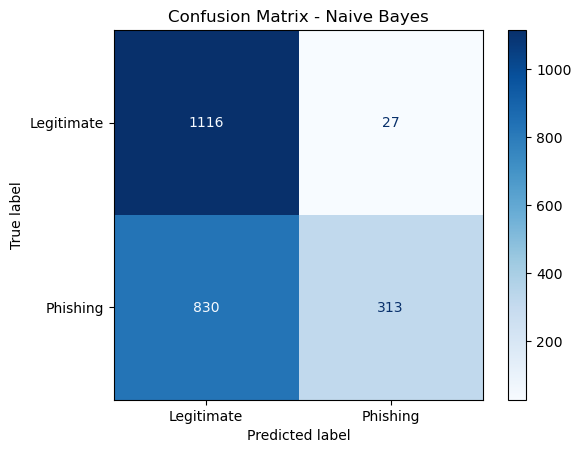

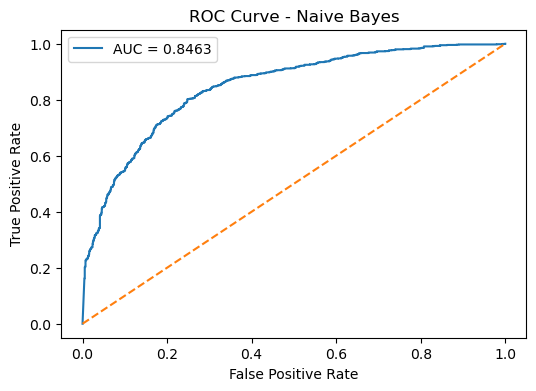


Модель: kNN
Accuracy : 0.8473
Precision: 0.8482
Recall   : 0.846
F1-score : 0.8471
ROC-AUC  : 0.9175

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.85      0.85      1143
    Phishing       0.85      0.85      0.85      1143

    accuracy                           0.85      2286
   macro avg       0.85      0.85      0.85      2286
weighted avg       0.85      0.85      0.85      2286



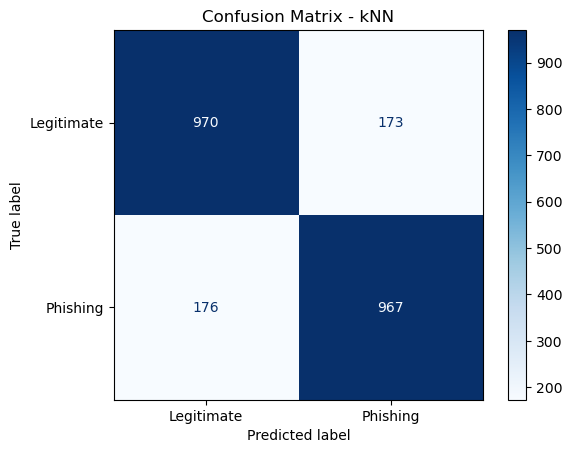

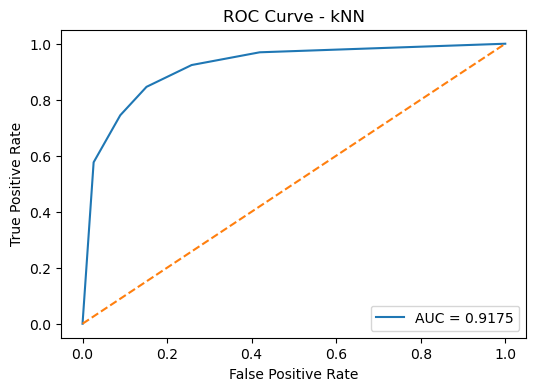


Модель: SVM
Accuracy : 0.8311
Precision: 0.865
Recall   : 0.7848
F1-score : 0.8229
ROC-AUC  : 0.9051

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.80      0.88      0.84      1143
    Phishing       0.86      0.78      0.82      1143

    accuracy                           0.83      2286
   macro avg       0.83      0.83      0.83      2286
weighted avg       0.83      0.83      0.83      2286



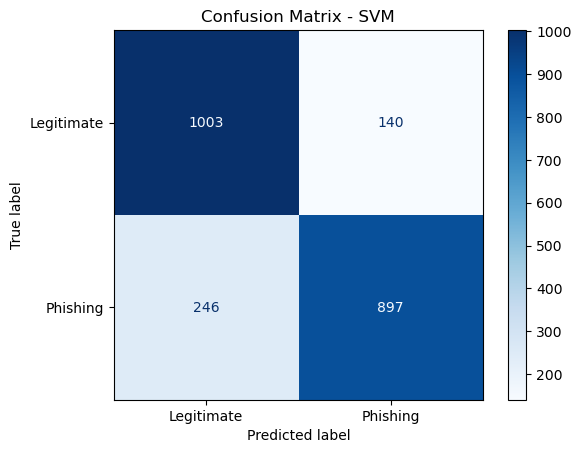

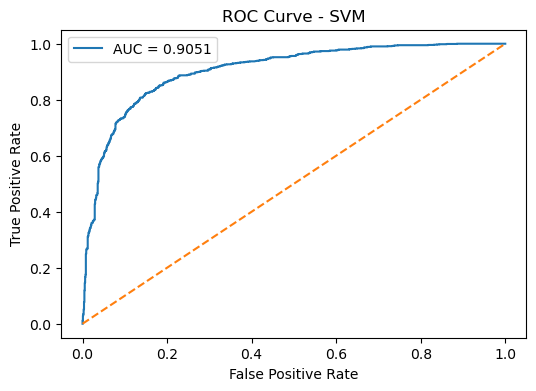


Модель: Decision Tree
Accuracy : 0.811
Precision: 0.8402
Recall   : 0.7682
F1-score : 0.8026
ROC-AUC  : 0.8897

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.79      0.85      0.82      1143
    Phishing       0.84      0.77      0.80      1143

    accuracy                           0.81      2286
   macro avg       0.81      0.81      0.81      2286
weighted avg       0.81      0.81      0.81      2286



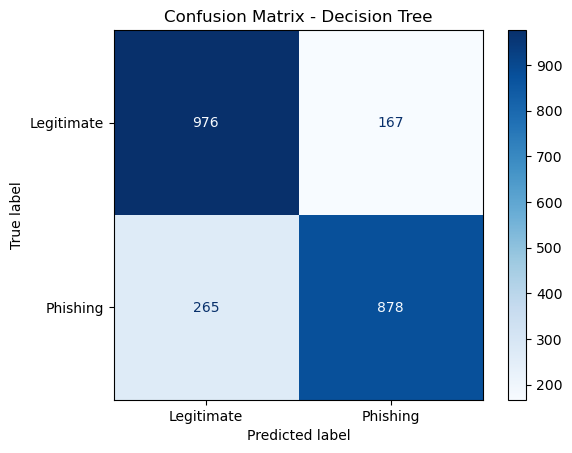

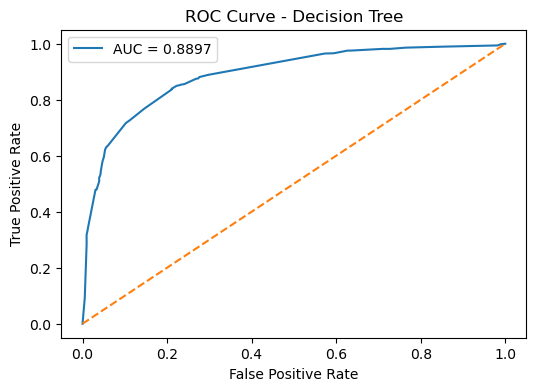


Модель: Random Forest
Accuracy : 0.8675
Precision: 0.8791
Recall   : 0.8521
F1-score : 0.8654
ROC-AUC  : 0.9455

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.86      0.88      0.87      1143
    Phishing       0.88      0.85      0.87      1143

    accuracy                           0.87      2286
   macro avg       0.87      0.87      0.87      2286
weighted avg       0.87      0.87      0.87      2286



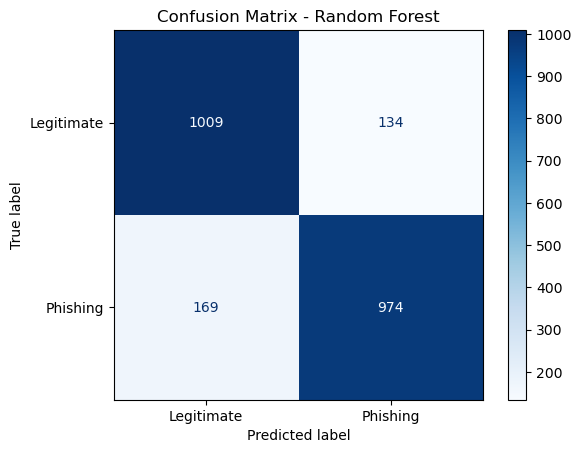

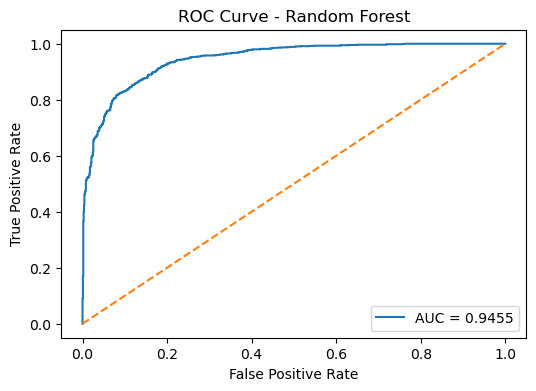


Итоговая таблица сравнения моделей:
           model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Random Forest  0.867454   0.879061  0.852143  0.865393  0.945540
1            kNN  0.847332   0.848246  0.846019  0.847131  0.917454
2            SVM  0.831146   0.864995  0.784777  0.822936  0.905143
3  Decision Tree  0.811024   0.840191  0.768154  0.802559  0.889662
4    Naive Bayes  0.625109   0.920588  0.273841  0.422117  0.846305


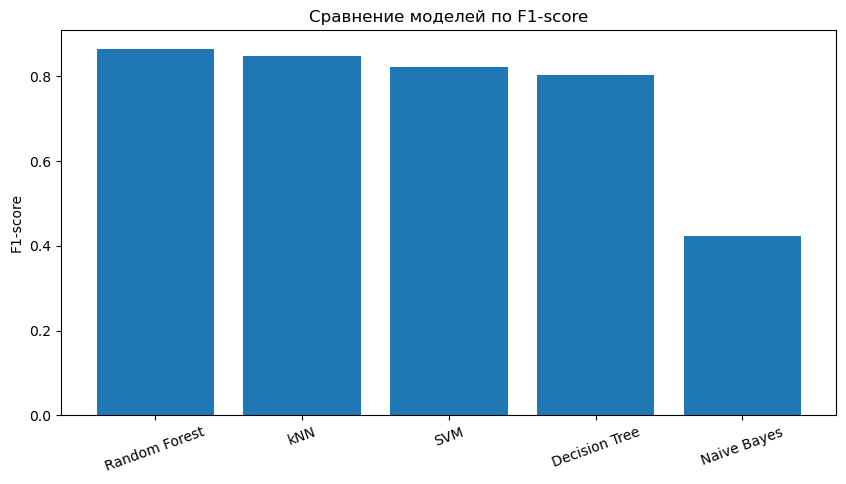

In [17]:
results = []

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Вероятности для ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Для моделей без predict_proba
        y_proba = None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    results.append({
        "model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"\n{'='*50}")
    print(f"Модель: {model_name}")
    print(f"{'='*50}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4) if not np.isnan(roc_auc) else "N/A")
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    # ROC-кривая
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()


for name, model in models.items():
    evaluate_model(
        name, model,
        X_train, y_train,
        X_test, y_test
    )

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

print("\nИтоговая таблица сравнения моделей:")
print(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["F1"])
plt.title("Сравнение моделей по F1-score")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.show()

In [19]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

import random
random.seed(52) 
sample_indices = random.sample(list(X_test.index), 5)

print("\nПримеры предсказаний для модели", best_model_name)
print("-" * 80)
print(f"{'URL':<60} | {'Реальный класс':<15} | {'Предсказанный класс':<15}")
print("-" * 80)

results_df_test = pd.DataFrame({
    'url': df.loc[X_test.index, 'url'],
    'real': y_test,
    'pred': y_pred_best
}, index=X_test.index)

for idx in sample_indices:
    row = results_df_test.loc[idx]
    print(f"{row['url'][:60]:<60} | {row['real']:<15} | {row['pred']:<15}")


Примеры предсказаний для модели Random Forest
--------------------------------------------------------------------------------
URL                                                          | Реальный класс  | Предсказанный класс
--------------------------------------------------------------------------------
https://mprestige.com.ua/                                    | 0               | 0              
https://twitter.com/mp3clan                                  | 0               | 0              
https://www.rockpapershotgun.com/2015/06/12/best-adventure-g | 0               | 0              
http://zohard.com/.well-known/pki-validation/mod/unblockveri | 1               | 1              
http://albel.intnet.mu/File/file_doc.php?l=_JeHFUq_VJOXJoGYD | 1               | 1              


In [18]:
print("\nK-Fold cross-validation (5 folds):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
    print(f"{name}: mean F1 = {scores.mean():.4f}, std = {scores.std():.4f}")





K-Fold cross-validation (5 folds):
Naive Bayes: mean F1 = 0.4043, std = 0.0149
kNN: mean F1 = 0.8476, std = 0.0093
SVM: mean F1 = 0.8080, std = 0.0070
Decision Tree: mean F1 = 0.8025, std = 0.0116
Random Forest: mean F1 = 0.8557, std = 0.0073
